In [2]:


import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [3]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
import os

dataset_path = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/train"

total = 0

print("-"*45)
print("{:<25} {:>10}".format("Class", "Images"))
print("-"*45)

for cls in sorted(os.listdir(dataset_path)):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        total += count
        print("{:<25} {:>10}".format(cls, count))

print("-"*45)
print("{:<25} {:>10}".format("TOTAL", total))

---------------------------------------------
Class                         Images
---------------------------------------------
Dermatitis                       546
Fungal_infections                375
Healthy                          492
Hypersensitivity                 230
demodicosis                      588
ringworm                         791
---------------------------------------------
TOTAL                           3022


In [5]:
from sklearn.metrics import classification_report

predictions_mob = mobilenet_model.predict(test_data)
y_pred_mob = np.argmax(predictions_mob, axis=1)

print(classification_report(
    test_data.classes,
    y_pred_mob,
    target_names=list(test_data.class_indices.keys())
))

NameError: name 'mobilenet_model' is not defined

In [6]:
import tensorflow as tf
import sys

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

2026-06-30 21:50:05.641824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782856205.965654      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782856206.058096      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782856206.798241      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782856206.798301      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782856206.798305      58 computation_placer.cc:177] computation placer alr

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.19.0


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [8]:
train_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/train"

valid_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid"

test_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test"

print("Paths Set Successfully")

Paths Set Successfully


In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [10]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_data.class_indices)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
{'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}


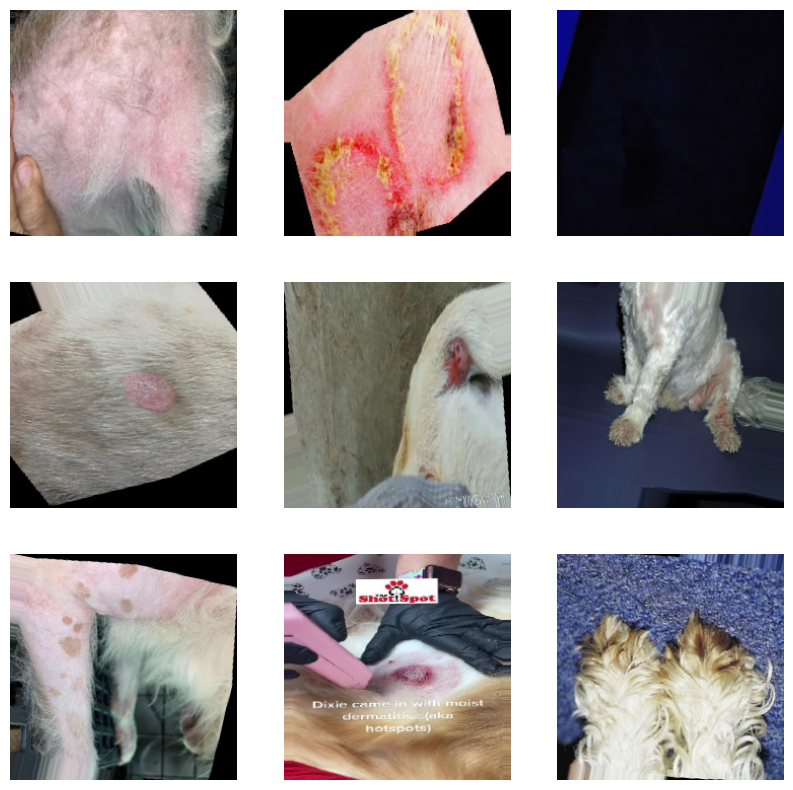

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [13]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-30 21:51:06.024994: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.3114 - loss: 1.8403 - val_accuracy: 0.3640 - val_loss: 1.6107
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.3782 - loss: 1.5725 - val_accuracy: 0.3849 - val_loss: 1.5097
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.3958 - loss: 1.5157 - val_accuracy: 0.3802 - val_loss: 1.4991
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.4060 - loss: 1.4439 - val_accuracy: 0.3884 - val_loss: 1.5222
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.4368 - loss: 1.3994 - val_accuracy: 0.4407 - val_loss: 1.4282
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.4378 - loss: 1.3766 - val_accuracy: 0.4221 - val_loss: 1.3780
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.4540 - loss: 1.3385 - val_accuracy: 0.4593 - val_loss: 1.3282
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.4570 - loss: 1.3262 - val_accuracy: 0.4651 - v

In [35]:
import time
import numpy as np

test_data.reset()

start = time.time()

predictions = mobilenet_model.predict(test_data, verbose=0)

end = time.time()

total_time = end - start
per_image = total_time / test_data.samples

print("Total inference time:", total_time, "seconds")
print("Inference time per image:", per_image*1000, "ms")

Total inference time: 8.490610361099243 seconds
Inference time per image: 19.608799910159917 ms


In [36]:
start = time.time()

predictions = cnn_model.predict(test_data, verbose=0)

end = time.time()

print("Total inference time:", end-start)
print("Inference per image:", ((end-start)/test_data.samples)*1000, "ms")

Total inference time: 6.630071640014648
Inference per image: 15.311943741373321 ms


In [17]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [18]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


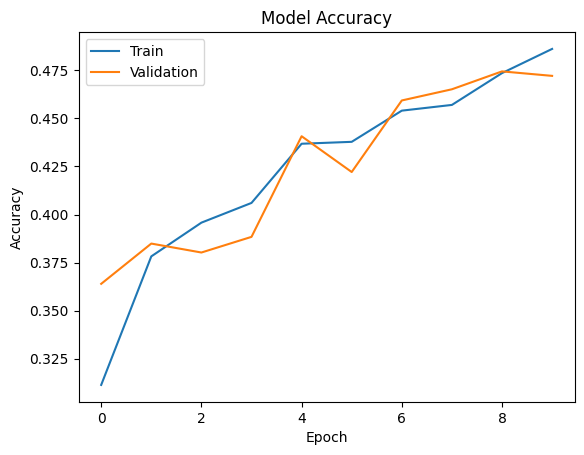

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('accuracy_curve.png')
plt.show()

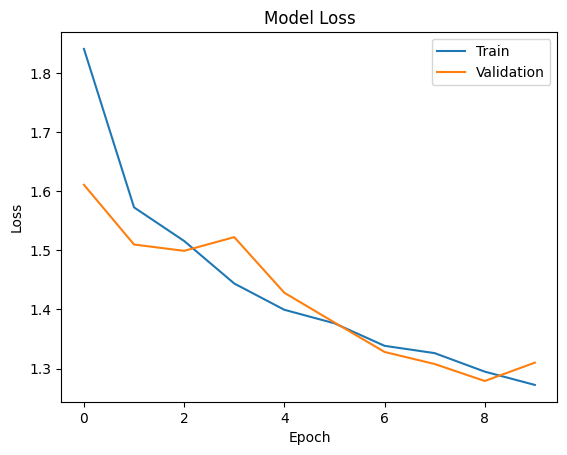

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('loss_curve.png')
plt.show()

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input,
                        outputs=predictions)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 2,388,614 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [24]:
import numpy as np

predictions = cnn_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step


In [22]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.6979 - loss: 0.8467 - val_accuracy: 0.2686 - val_loss: 7.5213
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.8005 - loss: 0.5765 - val_accuracy: 0.2535 - val_loss: 18.9631
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.8256 - loss: 0.5168 - val_accuracy: 0.2849 - val_loss: 6.6586
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.8412 - loss: 0.4583 - val_accuracy: 0.2523 - val_loss: 10.1616
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.8547 - loss: 0.3985 - val_accuracy: 0.2767 - val_loss: 12.7981
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 383s 4s/step - accuracy: 0.8733 - loss: 0.3764 - val_accuracy: 0.2593 - val_loss: 11.8098
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.8878 - loss: 0.3147 - val_accuracy: 0.2512 - val_loss: 14.7432
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.9034 - loss: 0.2787 - val_accuracy: 0.248

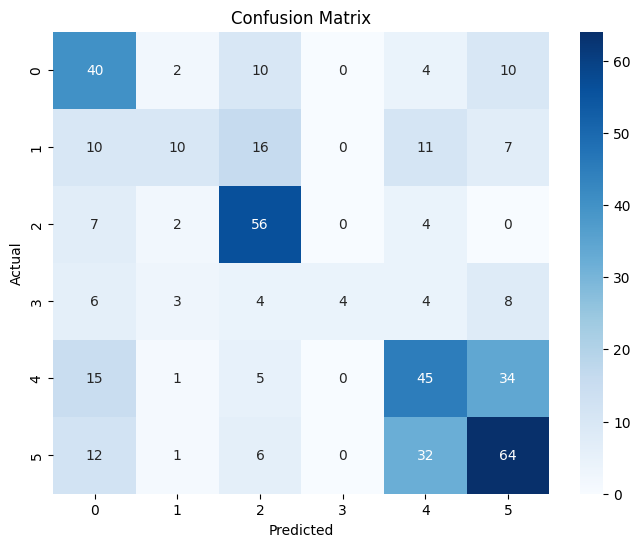

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_data.classes,
        y_pred,
        target_names=list(test_data.class_indices.keys())
    )
)

                   precision    recall  f1-score   support

       Dermatitis       0.44      0.61      0.51        66
Fungal_infections       0.53      0.19      0.27        54
          Healthy       0.58      0.81      0.67        69
 Hypersensitivity       1.00      0.14      0.24        29
      demodicosis       0.45      0.45      0.45       100
         ringworm       0.52      0.56      0.54       115

         accuracy                           0.51       433
        macro avg       0.59      0.46      0.45       433
     weighted avg       0.53      0.51      0.48       433



In [ ]:
cnn_model.save("livestock_skin_disease_model.h5")

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 589ms/step - accuracy: 0.1039 - loss: 2.3078
MobileNetV2 Test Accuracy: 0.10392609983682632
MobileNetV2 Test Loss: 2.3078339099884033


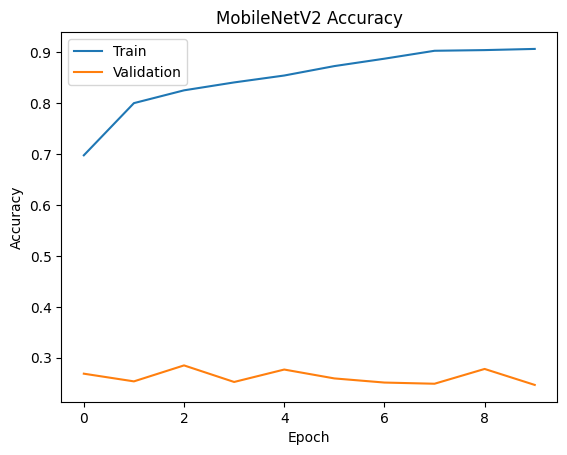

In [31]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_accuracy.png')
plt.show()

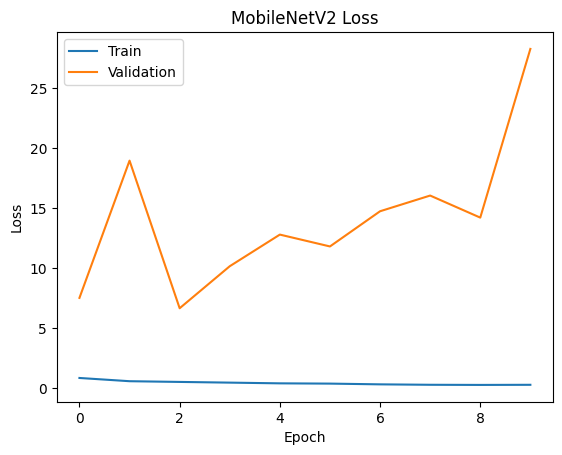

In [30]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_loss.png')
plt.show()

In [29]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 531ms/step - accuracy: 0.1039 - loss: 2.3078
MobileNetV2 Test Accuracy: 0.10392609983682632
MobileNetV2 Test Loss: 2.3078339099884033


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = mobilenet_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 669ms/step
                   precision    recall  f1-score   support

       Dermatitis       0.00      0.00      0.00        66
Fungal_infections       0.12      0.61      0.20        54
          Healthy       0.16      0.13      0.14        69
 Hypersensitivity       0.03      0.10      0.05        29
      demodicosis       0.00      0.00      0.00       100
         ringworm       0.00      0.00      0.00       115

         accuracy                           0.10       433
        macro avg       0.05      0.14      0.07       433
     weighted avg       0.04      0.10      0.05       433



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


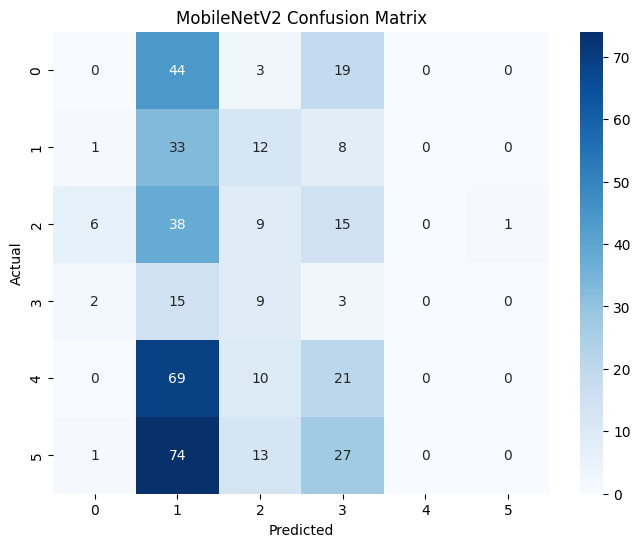

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("mobilenet_confusion_matrix.png")
plt.show()

In [39]:
for layer in base_model.layers:
    layer.trainable = False